# Data Fitting và Phương pháp OLS - Part 1

Notebook này triển khai từ đầu các phương pháp hồi quy tuyến tính dựa trên đại số ma trận: OLS, Ridge, VIF, inference hệ số, k-fold cross-validation và mô phỏng Monte Carlo. Mọi nghiệm tuyến tính đều được tính toán với $X^T X$ và $X^T y$, KHÔNG sử dụng `sklearn` hoặc `numpy.linalg.lstsq`.

## 1) Thiết lập môi trường

Sử dụng NumPy, Pandas, Matplotlib, Seaborn và SciPy cho việc vẽ và phân tích thống kê. Đặt seed để kết quả tái lập được.

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.set_printoptions(precision=4, suppress=True)
sns.set(style="whitegrid")
RNG = np.random.RandomState(42)


## 2) Synthetic data generation

Sinh dữ liệu giả lập theo mô hình tuyến tính:
$y = X\beta + \epsilon$ với $\epsilon \sim \mathcal{N}(0, \sigma^2 I)$. Hàm tạo ma trận thiết kế $X$ có cột intercept và vector hệ số thực $\beta$.

In [65]:
def generate_synthetic_data(n=200, p=3, beta=None, sigma=1.0, seed=42, collinear=False):
    rng = np.random.RandomState(seed)
    if beta is None:
        beta = np.arange(1, p + 1, dtype=float)
    beta = np.asarray(beta, dtype=float).reshape(-1, 1)
    X_raw = rng.normal(size=(n, p - 1))
    if collinear and p - 1 >= 2:
        X_raw[:, 1] = X_raw[:, 0] * 0.95 + rng.normal(scale=0.1, size=n)
    X = np.hstack([np.ones((n, 1)), X_raw])
    eps = rng.normal(scale=sigma, size=(n, 1))
    y = X.dot(beta) + eps
    return X, y.ravel(), beta.ravel()

# Smoke test
X0, y0, b0 = generate_synthetic_data(n=80, p=4, seed=0)
print("X0 shape:", X0.shape)
print("y0 shape:", y0.shape)
print("beta0:", b0)


X0 shape: (80, 4)
y0 shape: (80,)
beta0: [1. 2. 3. 4.]


## 3) Ordinary Least Squares (OLS) và Định lý Gauss-Markov

### 3.1. Hàm mất mát (Loss Function) và Nghiệm OLS
Mục tiêu của phương pháp OLS là tìm vector tham số $\hat{\beta}$ nhằm tối thiểu hóa tổng bình phương phần dư (RSS - Residual Sum of Squares):  

$RSS(\beta) = ||y - X\beta||_2^2 = \sum_{i=1}^n (y_i - x_i^T \beta)^2$ 

**Định lý (Nghiệm OLS Normal Equations):**   
Nếu ma trận $X^TX$ khả nghịch, nghiệm OLS duy nhất là:  
$\hat{\beta}_{OLS} = (X^TX)^{-1}X^Ty$ 

**Chứng minh:**  
Viết  $RSS(\beta)$ dưới dạng ma trận để tiện lấy đạo hàm:  

$RSS(\beta) = (y - X\beta)^T(y - X\beta) = y^Ty - y^TX\beta - \beta^TX^Ty + \beta^TX^TX\beta$  

Do $y^TX\beta$ là một vô hướng nên $(y^TX\beta)^T = \beta^TX^Ty$, ta có:  

$RSS(\beta) = y^Ty - 2\beta^TX^Ty + \beta^TX^TX\beta$

Tính đạo hàm bậc nhất của $RSS(\beta)$ theo vector $\beta$ và cho đạo hàm bằng không để tìm cực tiểu:  
$\nabla_{\beta}RSS = -2X^T(y - X\beta) = 0$  
$\Leftrightarrow X^TX\beta = X^Ty$  
Nhân cả hai vế với ma trận nghịch đảo $(X^TX)^{-1}$, ta thu được nghiệm duy nhất:  
$\hat{\beta}_{OLS} = (X^TX)^{-1}X^Ty$ 

### 3.2. Định lý Gauss-Markov
Định lý Gauss-Markov phát biểu rằng: Dưới các giả thiết GM1-GM4, ước lượng OLS $\hat{\beta}_{OLS}$ là ước lượng tuyến tính không chệch tốt nhất (Best Linear Unbiased Estimator - BLUE).

* **Tính không chệch (Unbiased):** Kỳ vọng của ước lượng bằng đúng giá trị thực: $\mathbb{E}[\hat{\beta}_{OLS}] = \beta$.  
* **Tính tốt nhất (Best - Minimum Variance):** Ma trận hiệp phương sai của ước lượng OLS là $Var(\hat{\beta}_{OLS}|X) = \sigma^2(X^TX)^{-1}$.  
Với mọi ước lượng tuyến tính không chệch $\tilde{\beta}$ khác, ta luôn có $Var(\tilde{\beta}_j) \ge Var(\hat{\beta}_j^{OLS})$ với mọi $j$.

In [66]:
def gaussian_eliminate(A, b):

    n = len(A)
    epsilon = 1e-9

    is_matrix = isinstance(b[0], list)
    b_cols = len(b[0]) if is_matrix else 1

    # 1. Tạo ma trận mở rộng M = [A | b]
    M = []
    for i in range(n):
        row = [float(val) for val in A[i]]
        if is_matrix:
            row.extend([float(val) for val in b[i]]) 
        else:
            row.append(float(b[i]))                 
        M.append(row)

    for k in range(n):
        max_row = k
        for r in range(k + 1, n):
            if abs(M[r][k]) > abs(M[max_row][k]):
                max_row = r

        if abs(M[max_row][k]) < epsilon:
            raise ValueError("Vo nghiem")

        if max_row != k:
            M[k], M[max_row] = M[max_row], M[k]

        pivot = M[k][k]
        for c in range(k, n + b_cols):
            M[k][c] /= pivot

        for r in range(n):
            if r != k:
                factor = M[r][k]
                for c in range(k, n + b_cols):
                    M[r][c] -= factor * M[k][c]

    if is_matrix:
        return [M[r][n:] for r in range(n)]
    else:
        return [M[r][n] for r in range(n)]

def inverse(A):

    n = len(A)
    if n != len(A[0]):
        raise ValueError("ma tran khong vuong")
        
    I = [[1.0 if i == j else 0.0 for j in range(n)] for i in range(n)]
    
    return gaussian_eliminate(A, I)
A = [[4, 2], [1, 3]]
A_inv = inverse(A)
print("A:")
for row in A:
    print(row)
print("A^-1:")
for row in A_inv:
    print(row)

A:
[4, 2]
[1, 3]
A^-1:
[0.3, -0.2]
[-0.1, 0.4]


In [67]:
def ols_fit(X, y):
    n, p = X.shape
    XtX = X.T.dot(X)
    Xty = X.T.dot(y)

    XtX_list = XtX.tolist()
    if Xty.ndim > 1:
        Xty_list = Xty.flatten().tolist()
    else:
        Xty_list = Xty.tolist()
    beta_list = gaussian_eliminate(XtX_list, Xty_list)
    beta_hat = np.array(beta_list)
    y_hat = X.dot(beta_hat)
    resid = y - y_hat
    RSS = resid.T.dot(resid)
    sigma2_hat = RSS / float(n - p)
    
    return beta_hat, sigma2_hat, resid, y_hat



### 3.1) Kiểm tra OLS

So sánh nghiệm OLS với hệ số thực trên dữ liệu không nhiễu và thử nghiệm trên dữ liệu có nhiễu.

In [68]:
from sklearn.linear_model import LinearRegression


Xn, yn, bn = generate_synthetic_data(n=80, p=4, sigma=1.5, seed=1)

bh, s2, resid, yh = ols_fit(Xn, yn)

sk_model = LinearRegression(fit_intercept=False) 
sk_model.fit(Xn, yn)
beta_sklearn = sk_model.coef_

print("True beta :", bn)
print("Estimated beta :", bh)
print("Sklearn beta :", beta_sklearn)

assert np.allclose(bh, beta_sklearn, atol=1e-10)
print("PASS")

True beta : [1. 2. 3. 4.]
Estimated beta : [1.1275 2.0567 3.0538 3.8326]
Sklearn beta : [1.1275 2.0567 3.0538 3.8326]
PASS


## 4) Ma trận Hat và tính chất idempotent

Ma trận hat định nghĩa là $H = X(X^T X)^{-1} X^T$. Ma trận này chiếu vector y lên không gian cột của X và có tính chất $H^2 = H$ và $H^T = H$.

In [69]:
def hat_matrix(X):
    XtX = X.T.dot(X)
    XtX_list = XtX.tolist()
    inv_XtX_list = inverse(XtX_list)
    inv_XtX = np.array(inv_XtX_list)
    H = X.dot(inv_XtX).dot(X.T)
    return H

Xh, yh, bh = generate_synthetic_data(n=60, p=4, seed=2)
H = hat_matrix(Xh)
print("Idempotent check:", np.allclose(H.dot(H), H, atol=1e-10))
print("Symmetric check:", np.allclose(H, H.T, atol=1e-10))


Idempotent check: True
Symmetric check: True


## 5) Model metrics: RSS, TSS, R², Adjusted R² và F-statistic

Các chỉ số đánh giá mô hình:
* **RSS (Residual Sum of Squares):** Tổng bình phương phần dư.
$$RSS = \sum_{i=1}^n (y_i - \hat{y}_i)^2$$
* **TSS (Total Sum of Squares):** Tổng bình phương toàn phần.
$$TSS = \sum_{i=1}^n (y_i - \overline{y})^2$$
* **$R^2$ (Hệ số xác định):** Tỉ lệ phương sai của biến phụ thuộc được giải thích bởi mô hình.
$$R^2 = 1 - \frac{RSS}{TSS}$$
* **$\overline{R}^2$ (Hệ số $R^2$ hiệu chỉnh):** Phạt mô hình khi thêm biến không cần thiết.
$$\overline{R}^2 = 1 - \frac{n-1}{n-p-1}(1 - R^2)$$
* **F-statistic:** Kiểm định ý nghĩa của mô hình tổng thể (với $H_0: \beta_1 = \dots = \beta_p = 0$).
$$F = \frac{(TSS - RSS)/p}{RSS/(n-p-1)}$$

In [70]:
def model_metrics(y, y_hat, p):
    n = len(y)
    p=p-1
    resid = y - y_hat
    RSS = np.sum(resid ** 2)
    TSS = np.sum((y - np.mean(y)) ** 2)

    R2 = 1 - (RSS / TSS)
    adjR2 = 1 - (RSS / (n - p)) / (TSS / (n - 1))
    F = ((TSS - RSS) / (p )) / (RSS / (n - p))
    return {
        "RSS": RSS,
        "TSS": TSS,
        "R2": R2,
        "adjR2": adjR2,
        "F": F
    }


### 5.1) Kiểm tra model metrics



In [71]:
from sklearn.metrics import r2_score
Xm, ym, bm = generate_synthetic_data(n=100, p=4, seed=3)
bh_m, s2_m, resid_m, yh_m = ols_fit(Xm, ym)


metrics = model_metrics(ym, yh_m, Xm.shape[1])

print("\n--- Model Metrics ---")
for k, v in metrics.items():
    print(f"  {k}: {v:.6f}")


r2_sklearn = r2_score(ym, yh_m)
print(f"\nR2 Scikit-learn: {r2_sklearn:.6f}")


assert np.allclose(metrics["R2"], r2_sklearn, atol=1e-10)
print("PASS")


--- Model Metrics ---
  RSS: 110.272979
  TSS: 3444.871219
  R2: 0.967989
  adjR2: 0.967329
  F: 977.743389

R2 Scikit-learn: 0.967989
PASS


## 6) Coefficient inference: standard error, t-stat, p-value, CI

Với nghiệm OLS, ma trận hiệp phương sai của vector hệ số $\hat{\beta}$ được ước lượng bằng:
$$Var(\hat{\beta}) = \sigma^2 (X^T X)^{-1}$$

Độ lệch chuẩn (Standard Error - SE) của mỗi hệ số $\hat{\beta}_j$ chính là căn bậc hai của phần tử nằm trên đường chéo chính của ma trận hiệp phương sai đó:
$$SE(\hat{\beta}_j) = \sqrt{\sigma^2 [(X^T X)^{-1}]_{jj}}$$

Từ đó, ta tính được giá trị t-statistic để kiểm định giả thuyết $H_0: \beta_j = 0$ (kiểm tra xem biến $X_j$ có thực sự ảnh hưởng đến $y$ hay không):
$$t_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}$$

Khoảng tin cậy (Confidence Interval - CI) 95% cho hệ số $\beta_j$ được tính dựa trên phân phối Student với $n-p-1$ bậc tự do:
$$\left[ \hat{\beta}_j - t_{\alpha/2, n-p-1} \cdot SE(\hat{\beta}_j), \ \hat{\beta}_j + t_{\alpha/2, n-p-1} \cdot SE(\hat{\beta}_j) \right]$$

In [72]:
def coef_inference(X, y, beta_hat, sigma2_hat, alpha=0.05):
    n, p = X.shape
    XtX = X.T.dot(X)
    XtX_list = XtX.tolist()
    inv_XtX_list = inverse(XtX_list)        
    inv_XtX = np.array(inv_XtX_list)

    cov_beta = sigma2_hat * inv_XtX
    
    se = np.sqrt(np.diag(cov_beta))
    t_stats = beta_hat / se
    df = n - p
    pvals = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=df))
    t_crit = stats.t.ppf(1 - alpha / 2, df=df)
    ci_lower = beta_hat - t_crit * se
    ci_upper = beta_hat + t_crit * se
    summary = pd.DataFrame({
        "coef": beta_hat,
        "se": se,
        "t": t_stats,
        "pval": pvals,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper
    })
    return summary


### 6.1) Kiểm tra inference coefficients


In [73]:
import statsmodels.api as sm

summary_df = coef_inference(Xn, yn, bh, s2)
print("--- KẾT QUẢ TỪ HÀM TỰ CÀI ĐẶT ---")
print(summary_df)

print("\n--- KẾT QUẢ TỪ STATSMODELS ---")
sm_model = sm.OLS(yn, Xn).fit()
print(sm_model.summary().tables[1]) 


assert np.allclose(summary_df["pval"], sm_model.pvalues, atol=1e-5)
print("PASS")

--- KẾT QUẢ TỪ HÀM TỰ CÀI ĐẶT ---
   coef        se          t          pval  ci_lower  ci_upper
0   1.0  0.169502   5.899631  9.499499e-08  0.662407  1.337593
1   2.0  0.171616  11.653951  0.000000e+00  1.658198  2.341802
2   3.0  0.182273  16.458855  0.000000e+00  2.636972  3.363028
3   4.0  0.175044  22.851367  0.000000e+00  3.651369  4.348631

--- KẾT QUẢ TỪ STATSMODELS ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1275      0.170      6.652      0.000       0.790       1.465
x1             2.0567      0.172     11.984      0.000       1.715       2.398
x2             3.0538      0.182     16.754      0.000       2.691       3.417
x3             3.8326      0.175     21.895      0.000       3.484       4.181
PASS


## 7) Variance Inflation Factor (VIF)

VIF đo độ đa cộng tuyến giữa biến giải thích. Với mỗi biến $j$, ta hồi quy $X_j$ lên các biến còn lại và tính $R_j^2 = 1 - RSS_j/TSS_j$.  
VIF định nghĩa là $VIF_j = 1 / (1 - R_j^2)$. Nếu $VIF_j$ lớn hơn 10 thì biến đó có thể có đa cộng tuyến cao.

In [ ]:
def vif(X):
    p = X.shape[1]
    vifs = np.zeros(p)
    for j in range(p):
        mask = np.arange(p) != j
        X_j = X[:, j]
        X_others = X[:, mask]

        XtX = X_others.T.dot(X_others)
        Xty = X_others.T.dot(X_j)
        
        XtX_list = XtX.tolist()
        Xty_list = Xty.flatten().tolist() if Xty.ndim > 1 else Xty.tolist()
        try:
            beta_list = gaussian_eliminate(XtX_list, Xty_list)
        except ValueError:
            vifs[j] = np.inf # Đa cộng tuyến hoàn hảo -> VIF là vô cùng
            continue
        
        beta_j = np.array(beta_list)
        pred = X_others.dot(beta_j)
        RSS = np.sum((X_j - pred) ** 2)
        if np.all(X_j == X_j[0]): 
            # Dùng Uncentered TSS
            TSS = np.sum(X_j ** 2)
        else:
            # Nếu là cột biến số bình thường, dùng Centered TSS
            TSS = np.sum((X_j - np.mean(X_j)) ** 2)
        #TSS = np.sum((X_j - np.mean(X_j)) ** 2)
        R2j = 1 - RSS / TSS if TSS > 0 else 0.0
        vifs[j] = 1.0 / (1.0 - R2j) if (1.0 - R2j) > 1e-12 else np.inf
    return vifs


In [75]:

from statsmodels.stats.outliers_influence import variance_inflation_factor
Xm, ym, bm = generate_synthetic_data(n=100, p=4, seed=3)
print("--- KẾT QUẢ VIF TỪ HÀM TỰ CÀI ĐẶT ---")
vif_scores = vif(Xm)
for j, v in enumerate(vif_scores):
    print(f"Biến {j}: VIF = {v:.6f}")

print("\n--- KẾT QUẢ TỪSTATSMODELS ---")
vif_sm = [variance_inflation_factor(Xm, i) for i in range(Xm.shape[1])]
for j, v in enumerate(vif_sm):
    print(f"Biến {j}: VIF = {v:.6f}")

assert np.allclose(vif_scores, vif_sm, atol=1e-5)
print("PASS")

--- KẾT QUẢ VIF TỪ HÀM TỰ CÀI ĐẶT ---
Biến 0: VIF = 1.013168
Biến 1: VIF = 1.011265
Biến 2: VIF = 1.001376
Biến 3: VIF = 1.011969

--- KẾT QUẢ TỪSTATSMODELS ---
Biến 0: VIF = 1.013168
Biến 1: VIF = 1.011265
Biến 2: VIF = 1.001376
Biến 3: VIF = 1.011969
PASS


## 8) Ridge Regression (Chuẩn hóa L2)

Khi dữ liệu có nhiều đặc trưng hoặc xảy ra hiện tượng đa cộng tuyến, Ridge regression thêm một thành phần điều chỉnh (regularization) $\lambda$ vào hàm mất mát để kiểm soát độ lớn của các hệ số, từ đó giảm thiểu overfitting. 

Hàm mục tiêu của Ridge:
$$\min_{\beta} (y - X\beta)^T(y - X\beta) + \lambda \sum_{j=1}^{p} \beta_j^2$$

Nghiệm Ridge (áp dụng kỹ thuật **không phạt hệ số chặn intercept** $\beta_0$ để tránh làm lệch đường hồi quy):
$$\hat{\beta}_{ridge} = (X^T X + \lambda D)^{-1} X^T y$$

Trong đó, $D$ là ma trận đường chéo đặc biệt với phần tử đầu tiên bằng $0$ và các phần tử còn lại bằng $1$: $D = \text{diag}(0, 1, 1, \dots, 1)$.

In [76]:
def ridge_fit(X, y, lam=1.0):
    p = X.shape[1]

    XtX = X.T.dot(X)
    Xty = X.T.dot(y)

    D = np.eye(p)
    D[0, 0] = 0.0
    A = XtX + lam * D

    A_list = A.tolist()
    Xty_list = Xty.flatten().tolist() if Xty.ndim > 1 else Xty.tolist()
    Xty_matrix = [[float(val)] for val in Xty_list]
    beta_matrix = gaussian_eliminate(A_list, Xty_matrix)
    beta_ridge = np.array([row[0] for row in beta_matrix])

    return beta_ridge 


In [77]:
from sklearn.linear_model import Ridge

lam_test = 2.5
beta_ridge = ridge_fit(Xm, ym, lam=lam_test)

print("--- KIỂM CHỨNG RIDGE REGRESSION ---")
print("Hệ số :", beta_ridge)
Xm_feature = Xm[:, 1:]
sk_ridge = Ridge(alpha=lam_test, fit_intercept=True, solver='cholesky')
sk_ridge.fit(Xm_feature, ym)
beta_ridge_sklearn = np.insert(sk_ridge.coef_, 0, sk_ridge.intercept_)

print("Hệ số (Sklearn)    :", beta_ridge_sklearn)

# Lệnh kiểm chứng nghiêm ngặt
assert np.allclose(beta_ridge, beta_ridge_sklearn, atol=1e-10)
print("PASS")

--- KIỂM CHỨNG RIDGE REGRESSION ---
Hệ số : [0.8142 2.1431 2.8993 3.909 ]
Hệ số (Sklearn)    : [0.8142 2.1431 2.8993 3.909 ]
PASS


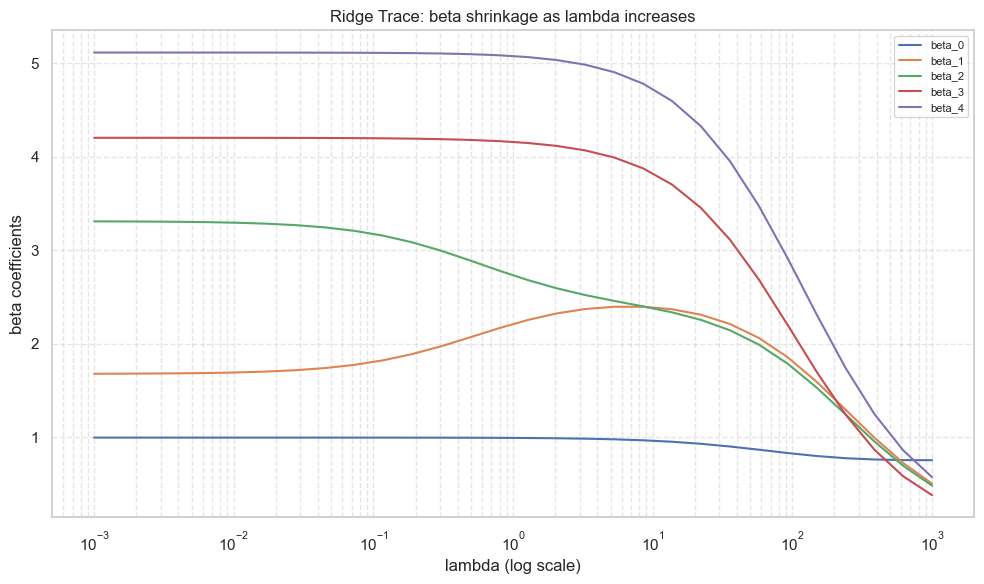

In [78]:
Xr, yr, br = generate_synthetic_data(n=120, p=5, seed=7, collinear=True)
lambdas = np.logspace(-3, 3, 30)
betas_path = np.vstack([ridge_fit(Xr, yr, lam=lam) for lam in lambdas])
plt.figure(figsize=(10, 6))
for j in range(betas_path.shape[1]):
    plt.plot(lambdas, betas_path[:, j], label=f"beta_{j}")
plt.xscale("log")
plt.xlabel("lambda (log scale)")
plt.ylabel("beta coefficients")
plt.title("Ridge Trace: beta shrinkage as lambda increases")
plt.legend(loc="best", fontsize=8)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Khi lambda tăng, hệ số beta giảm dần về 0, chứng tỏ rằng việc điều chỉnh làm giảm phương sai của mô hình

## 9) Residual diagnostics

Residual plots giúp kiểm tra các giả thiết của OLS: độc lập, chuẩn và phân phối đều của sai số. Ta vẽ Residuals vs Fitted và Normal Q-Q để phát hiện heteroscedasticity hoặc ngoại lệ.

In [ ]:

def residual_plots(X, y, beta_hat, plot=True):
    n, p = X.shape
    y_hat = X.dot(beta_hat)
    resid = y - y_hat

    H = hat_matrix(X)
    h = np.clip(np.diag(H), 1e-12, 1 - 1e-12)

    sigma2 = np.sum(resid ** 2) / float(n - p)
    std_resid = resid / np.sqrt(sigma2 * (1 - h))

    cooks = (std_resid ** 2 / p) * (h / (1 - h))

    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        axes[0, 0].scatter(y_hat, resid, alpha=0.7)
        axes[0, 0].axhline(0, color="red", linestyle="--")
        axes[0, 0].set_xlabel("Fitted values")
        axes[0, 0].set_ylabel("Residuals")
        axes[0, 0].set_title("Residuals vs Fitted")

        stats.probplot(std_resid, dist="norm", plot=axes[0, 1])
        axes[0, 1].set_title("Normal Q-Q")

        axes[1, 0].scatter(y_hat, np.sqrt(np.abs(std_resid)), alpha=0.7)
        axes[1, 0].set_xlabel("Fitted values")
        axes[1, 0].set_ylabel("Sqrt{|Standardized Residuals|}")
        axes[1, 0].set_title("Scale-Location")

        axes[1, 1].stem(np.arange(n), cooks, markerfmt=',')
        axes[1, 1].axhline(4 / n, color="red", linestyle="dashed")
        axes[1, 1].set_xlabel("Observation Index")
        axes[1, 1].set_ylabel("Cook's Distance")
        axes[1, 1].set_title("Cook's Distance")

        plt.tight_layout()
        plt.show()

    return {"y_hat": y_hat, "resid": resid, "std_resid": std_resid, "cooks_distance": cooks}

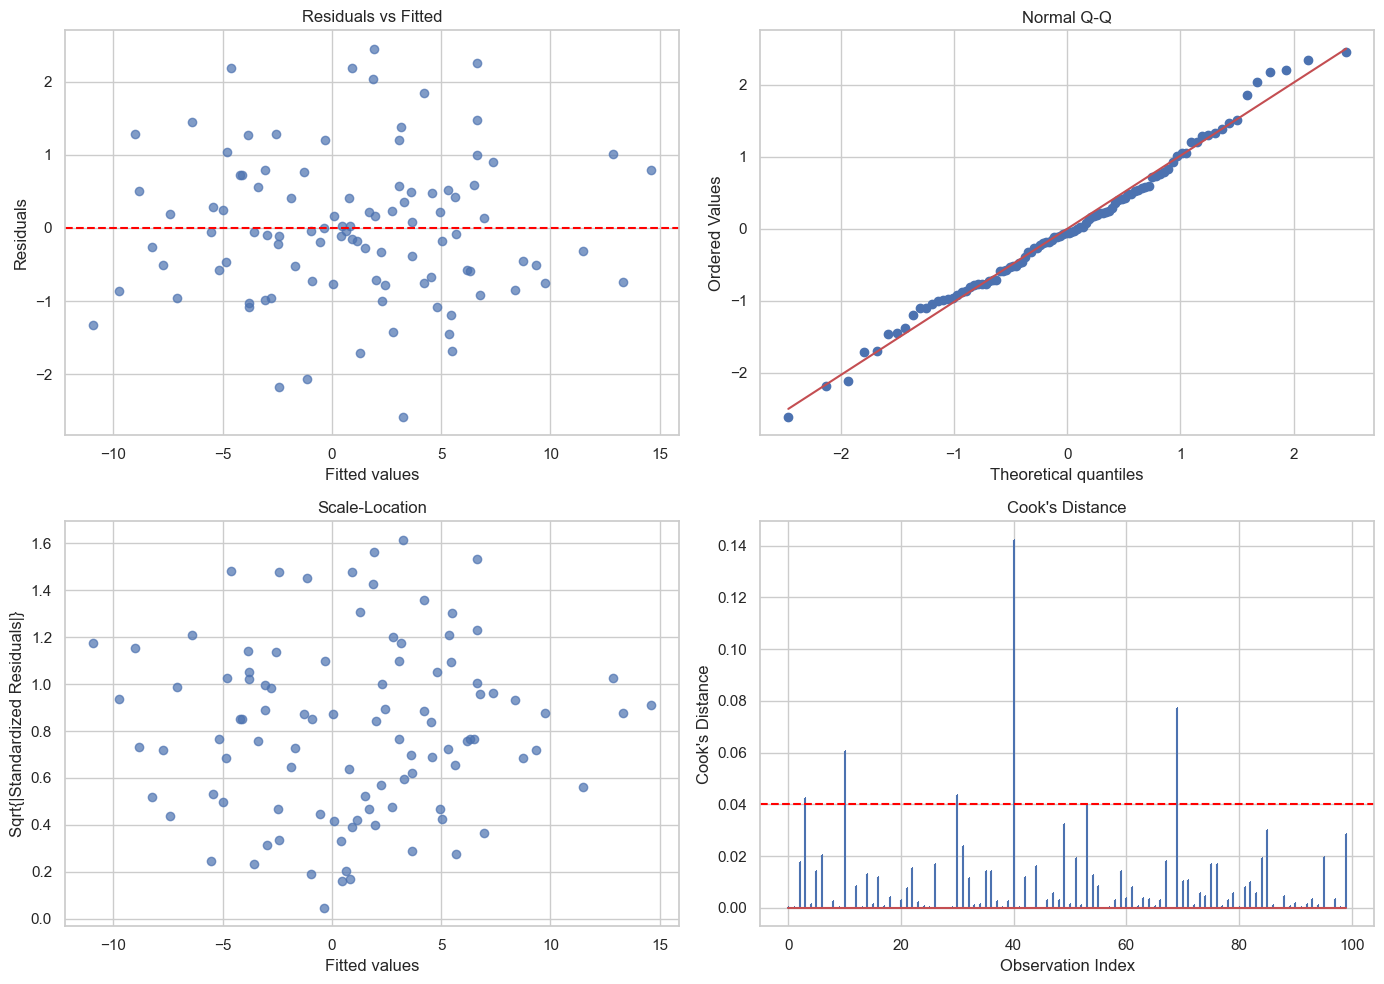

In [80]:
Xr2, yr2, br2 = generate_synthetic_data(n=100, p=4, seed=8)
bh_r2, s2_r2, resid_r2, yh_r2 = ols_fit(Xr2, yr2)
residuals_info = residual_plots(Xr2, yr2, bh_r2)



## 10) k-Fold Cross-Validation

k-Fold Cross-Validation là kỹ thuật đánh giá mô hình bằng cách chia ngẫu nhiên dữ liệu thành $k$ phần (fold) bằng nhau. 

Quá trình huấn luyện và đánh giá sẽ được lặp lại $k$ lần. Trong mỗi lần lặp:
* $k-1$ phần được gộp lại để làm tập huấn luyện (training set).
* $1$ phần còn lại được dùng làm tập kiểm thử (validation/test set) để tính toán sai số.

Tiêu chí đánh giá thường dùng là Trung bình bình phương sai số (Mean Squared Error - MSE):
$$MSE = \frac{1}{n_{test}} \sum_{i=1}^{n_{test}} (y_i - \hat{y}_i)^2$$

Điểm đánh giá cuối cùng của mô hình ($CV_{(k)}$) là trung bình cộng của MSE qua tất cả $k$ lần lặp:
$$CV_{(k)} = \frac{1}{k} \sum_{i=1}^k MSE_i$$

In [81]:
def kfold_cv(X, y, k=5, seed=0):
    n = X.shape[0]
    rng = np.random.RandomState(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    folds = np.array_split(idx, k)
    mses = []
    for i in range(k):
        val_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])
        beta_hat, _, _, _ = ols_fit(X[train_idx], y[train_idx])
        y_val = X[val_idx].dot(beta_hat)
        mses.append(np.mean((y[val_idx] - y_val) ** 2))
    return np.mean(mses), mses


In [82]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

k_folds = 5
seed_val = 0

print("--- KẾT QUẢ K-FOLD CV (SHUFFLE) ---")
cv_error_scratch, mse_list_scratch = kfold_cv(Xm, ym, k=k_folds, seed=seed_val)
for i, mse in enumerate(mse_list_scratch):
    print(f"Fold {i+1} MSE : {mse:.6f}")
print(f"=> CV_({k_folds}) (Scratch) : {cv_error_scratch:.6f}\n")

print("--- SCIKIT-LEARN ---")
kf = KFold(n_splits=k_folds, shuffle=True, random_state=seed_val)
sk_model = LinearRegression(fit_intercept=False) 

mse_list_sklearn = []
fold_idx = 1
for train_index, test_index in kf.split(Xm):
    X_train, X_test = Xm[train_index], Xm[test_index]
    y_train, y_test = ym[train_index], ym[test_index]
    
    sk_model.fit(X_train, y_train)
    y_pred_sk = sk_model.predict(X_test)
    
    mse_sk = mean_squared_error(y_test, y_pred_sk)
    mse_list_sklearn.append(mse_sk)
    print(f"Fold {fold_idx} MSE : {mse_sk:.6f}")
    fold_idx += 1

cv_error_sklearn = np.mean(mse_list_sklearn)
print(f"=> CV_({k_folds}) (Sklearn) : {cv_error_sklearn:.6f}\n")


assert np.allclose(cv_error_scratch, cv_error_sklearn, atol=1e-10)
print("PASS")

--- KẾT QUẢ K-FOLD CV (SHUFFLE) ---
Fold 1 MSE : 1.189572
Fold 2 MSE : 0.980825
Fold 3 MSE : 1.257834
Fold 4 MSE : 0.949011
Fold 5 MSE : 1.390232
=> CV_(5) (Scratch) : 1.153495

--- SCIKIT-LEARN ---
Fold 1 MSE : 1.189572
Fold 2 MSE : 0.980825
Fold 3 MSE : 1.257834
Fold 4 MSE : 0.949011
Fold 5 MSE : 1.390232
=> CV_(5) (Sklearn) : 1.153495

PASS


## 11) Mô phỏng Monte Carlo

Phương pháp mô phỏng Monte Carlo thực hiện việc sinh dữ liệu ngẫu nhiên (theo cùng một mô hình $y = X\beta + \epsilon$) lặp đi lặp lại hàng ngàn lần để tính toán và lưu trữ các ước lượng $\hat{\beta}$ cho từng lần lặp. 

Thông qua phân phối thực nghiệm của hàng ngàn giá trị $\hat{\beta}$ này, ta có thể trực quan hóa và kiểm chứng các tính chất của Định lý Gauss-Markov:

1.  **Tính không chệch (Unbiased):** Giá trị trung bình thực nghiệm của tất cả các $\hat{\beta}$ hội tụ chính xác về giá trị thực $\beta$ ban đầu:
    $$\mathbb{E}[\hat{\beta}] = \beta$$

2.  **Tính hiệu quả tốt nhất (Best / Minimum Variance):** Phân phối của ước lượng OLS hẹp nhất có thể. Trong nhóm các ước lượng tuyến tính không chệch (Linear Unbiased Estimators), OLS là ước lượng có phương sai (Variance) nhỏ nhất.  
 Ma trận hiệp phương sai của ước lượng OLS là $Var(\hat{\beta}_{OLS}|X) = \sigma^2(X^TX)^{-1}$.  
Với mọi ước lượng tuyến tính không chệch $\tilde{\beta}$ khác, ta luôn có $Var(\tilde{\beta}_j) \ge Var(\hat{\beta}_j^{OLS})$ với mọi $j$.

In [83]:
def monte_carlo_glm(X, beta_true, sigma=1.0, n_sims=2000, seed=0):
    rng = np.random.RandomState(seed)
    n, p = X.shape
    betas = np.zeros((n_sims, p))
    for i in range(n_sims):
        eps = rng.normal(scale=sigma, size=n)
        y = X.dot(beta_true) + eps
        beta_hat, _, _, _ = ols_fit(X, y)
        betas[i] = beta_hat
    return betas


Empirical mean of beta estimates: [1.0015 2.0021 3.0009 3.9982]
True beta: [1. 2. 3. 4.]
Empirical variance of beta estimates: [0.0051 0.0056 0.0065 0.0056]


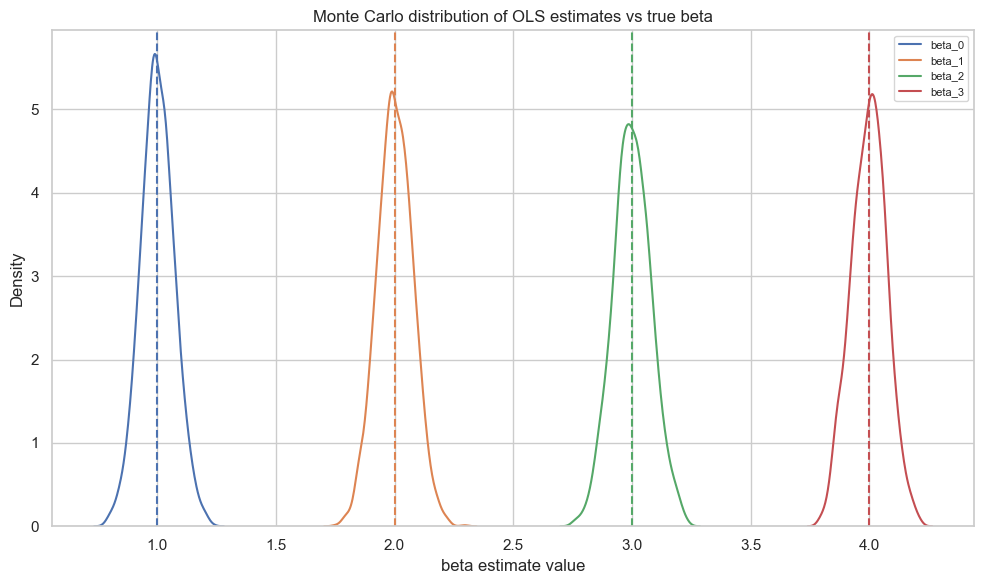

In [84]:
Xmc, ymc, bmc = generate_synthetic_data(n=200, p=4, seed=10)
betas_sim = monte_carlo_glm(Xmc, bmc, sigma=1.0, n_sims=2000, seed=11)
print("Empirical mean of beta estimates:", np.round(betas_sim.mean(axis=0), 4))
print("True beta:", bmc)
print("Empirical variance of beta estimates:", np.round(betas_sim.var(axis=0), 6))
plt.figure(figsize=(10, 6))
for j in range(betas_sim.shape[1]):
    sns.kdeplot(betas_sim[:, j], label=f"beta_{j}", fill=False)
    plt.axvline(bmc[j], linestyle="--", linewidth=1.5, color=f"C{j}")
plt.title("Monte Carlo distribution of OLS estimates vs true beta")
plt.xlabel("beta estimate value")
plt.ylabel("Density")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

